In [66]:
import os 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
from PIL import Image
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import KFold
from collections import Counter               
import albumentations as A

from scipy.ndimage import label
from scipy.ndimage import distance_transform_edt
import matplotlib.pyplot as plt



device = torch.device('mps' if torch.backends.mps.is_available() else 
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [91]:
class Config:
    # Path
    volumes_path = 'data/EM_train-volume.tif'
    label_path = 'data/EM_train-labels.tif'
    test_path='data/EM_test-volume.tif'

    # Dataset
    train_ratio=1
    alpha=1000
    sigma=10
    # Weight map
    w0=10
    sigma_weight=5

    # Model
    input_channel=1
    output_channel=2

    # Training
    batch_size=4
    num_epochs=300
    momentum=0.99
    lr_rate = 0.01
    weigth_decay=1e-4

    #K-fold
    n_folds =5

    threshold=0.3

config =Config()

In [92]:
class EMDataset(Dataset):
    def __init__(self, img_path, label_path=None, transform=None, is_train=True, indices=None):
        self.img_path = img_path
        self.label_path = label_path
        self.transform = transform
        self.indices=indices
        self.is_train = is_train

        # train or test images
        images =[]
        with Image.open(img_path) as image:
            for i in range(image.n_frames):
                image.seek(i)
                img_frame = np.array(image, dtype=np.float32)
                images.append(img_frame)

        # label images
        labels=[]
        if label_path is not None:
            with Image.open(label_path) as label:
                for i in range(label.n_frames):
                    label.seek(i)
                    label_frame = np.array(label, dtype=np.float32)
                    labels.append(label_frame)
        
        if indices is not None:
            self.images = [images[i] for i in indices]
            self.labels = [labels[i] for i in indices] if labels is not None else None
        else:
            self.images = images
            self.labels = labels

    def __len__(self):
        return len(self.images)
    
    def compute_weight_map(self, mask):
        weight_map =np.ones_like(mask, dtype=np.float32)

        labeled_label, num_cells=label(mask>0)

        if num_cells<2:
            return weight_map
        
        distances=[]
        for cell_id in range(1, num_cells+1):
            cell_label = (labeled_label == cell_id)
            distance = distance_transform_edt(~cell_label)
            distances.append(distance)
        
        distances=np.array(distances)
        distances_sort=np.sort(distances, axis=0)
        d1= distances_sort[0]
        d2 =distances_sort[1] if len(distances)>1 else d1

        weight_map = weight_map+config.w0*np.exp(-((d1+d2)**2)/(2*(config.sigma_weight**2)))
        return weight_map.astype(np.float32)

    
    def __getitem__(self, idx):
        image = self.images[idx].copy()

        if self.labels is not None:
            label = self.labels[idx].copy()

            if self.transform:
                transformed = self.transform(image=image, mask=label)
                image = transformed['image']
                label = transformed['mask']
            else: # Transform이 없으면 최소한 tensor로 변환
                image = torch.from_numpy(image).unsqueeze(0)
                label = torch.from_numpy(label).unsqueeze(0)
            
            if label.dim() ==2:
                label=label.unsqueeze(0)
            label_binary = (label>0).float()
            if label_binary.dim() == 2:  # [H, W]
                label_binary = label_binary.unsqueeze(0)  # [1, H, W]
        

            label_binary =(label>0).float()

            weight_map=self.compute_weight_map(label.squeeze().numpy())
            weight_map=torch.from_numpy(weight_map).unsqueeze(0)

            return {
                'image': image,
                'mask': label_binary,
                'weight_map': weight_map,
                'idx': idx
            }
        else: # Label이 없을 때; Test
            if self.transform:
                transformed = self.transform(image=image)
                image = transformed['image']
            else:
                image = torch.from_numpy(image).unsqueeze(0)
            return {
                'image': image,
                'idx': idx
            }

In [93]:
def train_transform():
    return A.Compose([
        A.ElasticTransform(
            alpha=config.alpha,
            sigma=config.sigma,
            p=0.5          
        ),

        #원래 논문 크기대로
        A.Resize(572, 572),

        #추가 Augmentation 논문에서 자세한 설정값 제시 X
        A.RandomRotate90(p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),

        A.Normalize(
            mean=0.0,
            std=1.0,
            max_pixel_value=255.0
        ),
        ToTensorV2()
    ])
def val_transform():
    return A.Compose([
        A.Normalize(mean=0.0, std=1.0, max_pixel_value=255.0),
        A.Resize(572, 572),
        ToTensorV2(),
    ])
def test_transform():
    return A.Compose([
        A.Normalize(mean=0.0, std=1.0, max_pixel_value=255.0),
        A.Resize(572, 572),
        ToTensorV2()
    ])

def train_val_split(img_path, label_path, val_ratio=config.train_ratio,seed=42):
    with Image.open(img_path) as img:
        total_size=img.n_frames
    print(f"전체 데이터: {total_size}개")

    indices = list(range(total_size))
    np.random.seed(seed)
    np.random.shuffle(indices)
    
    val_size = int(total_size * val_ratio)
    train_size = total_size - val_size
    
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    train_dataset = EMDataset(
        img_path=img_path,
        label_path=label_path,
        transform=train_transform(),
        indices=train_indices,
    )

    val_dataset=EMDataset(
        img_path=img_path,
        label_path=label_path,
        transform=val_transform(),
        indices=val_indices,
    )
    
    print(f"Train: {train_size}개, Validation: {val_size}개")
    return train_dataset, val_dataset



In [94]:
train_dataset, val_dataset = train_val_split(
        img_path=config.volumes_path,
        label_path=config.label_path,
        val_ratio=1-config.train_ratio,
        seed=42
    )

test_dataset = EMDataset(
    img_path=config.test_path,
    label_path=None,
    transform=test_transform()
)
train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
    )
    
val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False, 
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
)

sample = train_dataset[0]

x = sample['image']
y = sample['mask']

print(x.shape, y.shape)

전체 데이터: 30개
Train: 30개, Validation: 0개
torch.Size([1, 572, 572]) torch.Size([1, 572, 572])


In [95]:
class Conv2(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=0),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=0),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # Contracting path
        self.encoder1=Conv2(in_channels, 64)
        self.pool1=nn.MaxPool2d(2)

        self.encoder2=Conv2(64, 128)
        self.pool2=nn.MaxPool2d(2)

        self.encoder3=Conv2(128, 256)
        self.pool3=nn.MaxPool2d(2)

        self.encoder4=Conv2(256, 512)
        self.pool4=nn.MaxPool2d(2)

        self.bottleneck=Conv2(512,1024)

        # Expanding path
        self.upconv1=nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.decoder1=Conv2(1024, 512)

        self.upconv2=nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder2=Conv2(512, 256)

        self.upconv3=nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder3=Conv2(256, 128)

        self.upconv4=nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder4=Conv2(128, 64)

        # Final FCN
        self.fcn = nn.Conv2d(64, out_channels, kernel_size=1)
        #self._initialize_weights()

    def forward(self, x):
        enc1 = self.encoder1(x)
        x = self.pool1(enc1)

        enc2 = self.encoder2(x)
        x = self.pool2(enc2)

        enc3 = self.encoder3(x)
        x = self.pool3(enc3)

        enc4 = self.encoder4(x)
        x = self.pool4(enc4)

        x = self.bottleneck(x)

        x = self.upconv1(x)
        encoder4_cropped = self.crop(enc4, x)
        x= torch.cat([encoder4_cropped, x], dim=1)
        x= self.decoder1(x)

        x = self.upconv2(x)
        encoder3_cropped = self.crop(enc3, x)
        x= torch.cat([encoder3_cropped, x], dim=1)
        x= self.decoder2(x)

        x = self.upconv3(x)
        encoder2_cropped = self.crop(enc2, x)
        x= torch.cat([encoder2_cropped, x], dim=1)
        x= self.decoder3(x)

        x = self.upconv4(x)
        encoder1_cropped = self.crop(enc1, x)
        x= torch.cat([encoder1_cropped, x], dim=1)
        x= self.decoder4(x)

        return self.fcn(x)
    
    def crop(self, encoder_layer, decoder_layer):
        _, _, H, W = decoder_layer.size()
        encoder_cropped = transforms.CenterCrop([H,W])(encoder_layer)
        return encoder_cropped
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)


In [96]:
class WeightedCELoss(nn.Module):
    def __init__(self):
        super(WeightedCELoss, self).__init__()
    
    def forward(self, preds, targets, weight_maps):
        _, _, h, w = preds.shape
        
        if targets.shape[2:] != (h,w):
            targets = transforms.CenterCrop([h,w])(targets)
            weight_maps = transforms.CenterCrop([h, w])(weight_maps)
        
        bce_loss = F.binary_cross_entropy_with_logits(
            preds,
            targets,
            reduction='none'
        )
        weighted_loss = bce_loss*weight_maps

        return weighted_loss.mean()

In [97]:
class WeightedCELoss(nn.Module):
    def __init__(self, num_classes=2):
        super(WeightedCELoss, self).__init__()
        self.num_classes = num_classes
    
    def forward(self, outputs, targets, weight_maps):

        # Binary segmentation
        if self.num_classes == 1:
            bce_loss = F.binary_cross_entropy_with_logits(
                outputs, 
                targets, 
                reduction='none'  # 픽셀별 loss 계산
            )
            
            # Weight map 적용
            weighted_loss = bce_loss * weight_maps  # [B, 1, H, W]
            
            # 평균 계산
            loss = weighted_loss.mean()
            
        # Multi-class segmentation
        else:
            targets = targets.squeeze(1).long()  # [B, H, W]
            weight_maps = weight_maps.squeeze(1)  # [B, H, W]

            ce_loss = F.cross_entropy(
                outputs,
                targets,
                reduction='none'  # 픽셀별 loss 계산
            )
            # ce_loss: [B, H, W]
            
            # Weight map 적용
            weighted_loss = ce_loss * weight_maps
            
            # 평균 계산
            loss = weighted_loss.mean()
        
        return loss


class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, outputs, targets):
        # Softmax 적용
        outputs = torch.softmax(outputs, dim=1)[:, 1:, :, :]
        
        # Flatten
        outputs = outputs.reshape(-1)
        targets = targets.reshape(-1)
        
        # Dice coefficient 계산
        intersection = (outputs * targets).sum()
        dice = (2. * intersection + self.smooth) / (
            outputs.sum() + targets.sum() + self.smooth
        )
        
        # Dice loss = 1 - Dice coefficient
        return 1 - dice


class CombinedLoss(nn.Module):
    def __init__(self, num_classes=2, ce_weight=1.0, dice_weight=1.0):
        super(CombinedLoss, self).__init__()
        self.weighted_ce = WeightedCELoss(num_classes=num_classes)
        self.dice = DiceLoss()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
    
    def forward(self, outputs, targets, weight_maps):         
        ce_loss = self.weighted_ce(outputs, targets, weight_maps)
        dice_loss = self.dice(outputs, targets)
        
        combined_loss = self.ce_weight * ce_loss + self.dice_weight * dice_loss
        
        return combined_loss, ce_loss, dice_loss

In [98]:
def compute_iou(pred, target):
    intersection = (pred * target).sum()
    union = (pred + target).sum() - intersection
    
    if union == 0:
        return 1.0
    
    return float(intersection / union)

'''
Warping Error를 계산하는 데에는 해당 라이브러리를 사용하거나 직접 구현해야하는데, 굉장히 어렵고 이렇게 직접 구현했을 경우 확실치 못하다.
그렇기 때문에 빼는 선택을 진행하였다.


def compute_warping_error(pred, target):
    1. split error : 하나의 객체가 여러개로 분류된 경우
    2. merge error: 여러개의 객체가 하나로 합쳐진 경우

    batch_size = pred.shape[0]
    errors =[]

    for i in range(batch_size):
        pred_img = pred[i,0]
        target_img=target[i,0]
        
        # 베경 label==0을 제외
        pred_labeled, pred_num = label(pred_img > 0)
        target_labeled, target_num = label(target_img > 0)

        # 1. Split Error 계산
        split_error =0
        for target_id in range(1, target_num+1):
            target_mask = (target_labeled == target_id)
            overlapping_pred = np.unique(pred_labeled[target_mask])
            overlapping_pred = overlapping_pred[overlapping_pred>0]

            if len(overlapping_pred)>1:
                split_error += len(overlapping_pred)-1

        # 2. Merge Error 계산
        merge_error =0
        for pred_id in range(1, pred_num+1):
            pred_mask = (pred_labeled==pred_id)
            overlapping_target = np.unique(target_labeled[pred_mask])
            overlapping_target = overlapping_target[overlapping_target>0]

            if len(overlapping_target)>1:
                merge_error += len(overlapping_target)-1

        # 정규화
        total_objects = max(pred_num, target_num)
        if total_objects ==0:
            continue
        
        error = (split_error + merge_error) / total_objects
        errors.append(error)
    return np.mean(errors)
'''
    

def rand_error(pred_prob, target):
    """
    Rand Error (Rand Index의 오류율)
    픽셀 쌍들의 clustering 일치도를 측정/예측과 정답이 일치하는지 확인
    Foregroung-restricted Rand Error (ISBI 2012 공식 메트릭) > presicion/recall 분리 + threshold sweep
    배경(label==0) 제외, GT foreground 픽셀 쌍만으로 계산
    """
    thresholds = np.arange(0.1, 1.0, 0.1)
    batch_size = pred_prob.shape[0]
    best_fscores = []

    for i in range(batch_size):
        target_img = target[i, 0]
        target_labeled, _ = label(target_img > 0)

        # GT foreground 픽셀만
        fg_mask = target_labeled > 0
        if fg_mask.sum() < 2:
            continue

        target_fg = target_labeled[fg_mask]

        # target 쪽은 threshold와 무관 → 한번만 계산
        target_counts = Counter(target_fg.flatten())
        sum_bj2 = sum(c * (c - 1) / 2 for c in target_counts.values())

        best_f = 0
        for thresh in thresholds:
            # threshold별로 binarize → connected components
            pred_binary = (pred_prob[i, 0] > thresh).astype(np.float32)
            pred_labeled, _ = label(pred_binary > 0)
            pred_fg = pred_labeled[fg_mask]

            # contingency table
            pair_counts = Counter(zip(pred_fg.flatten(), target_fg.flatten()))
            sum_nij2 = sum(c * (c - 1) / 2 for c in pair_counts.values())

            pred_counts = Counter(pred_fg.flatten())
            sum_ai2 = sum(c * (c - 1) / 2 for c in pred_counts.values())

            # Rand Precision & Recall
            precision = sum_nij2 / sum_ai2 if sum_ai2 > 0 else 0
            recall = sum_nij2 / sum_bj2 if sum_bj2 > 0 else 0

            # F-score
            if precision + recall > 0:
                f_score = 2 * precision * recall / (precision + recall)
            else:
                f_score = 0

            best_f = max(best_f, f_score)

        best_fscores.append(1 - best_f)

    return np.mean(best_fscores) if best_fscores else 0.0


In [99]:
## TTA 추가!!
def tta_predict(model, image, device):
    """
    Test Time Augmentation: 4회전 x 2flip = 8가지 예측 평균
    """
    model.eval()
    predictions = []
    with torch.no_grad():
        for k in range(4):
            for flip in [False, True]:
                x = torch.rot90(image, k, dims=[2, 3])
                if flip:
                    x = torch.flip(x, dims=[3])
                pred = model(x.to(device))
                pred_prob = torch.softmax(pred, dim=1)
                if flip:
                    pred_prob = torch.flip(pred_prob, dims=[3])
                pred_prob = torch.rot90(pred_prob, -k, dims=[2, 3])
                predictions.append(pred_prob.cpu())
    return torch.stack(predictions, dim=0).mean(dim=0)

In [100]:
def center_crop(tensor, target_h, target_w):
    _, _, h, w = tensor.shape
    
    if h == target_h and w == target_w:
        return tensor
    
    start_h = (h - target_h) // 2
    start_w = (w - target_w) // 2
    
    return tensor[:, :, start_h:start_h+target_h, start_w:start_w+target_w]

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for batch in loader:
        imgs = batch['image'].to(device)
        masks = batch['mask'].to(device)
        wmaps = batch['weight_map'].float().to(device)

        preds = model(imgs)

        # 크기 맞추기
        _, _, h, w = preds.shape
        masks = center_crop(masks, h, w)
        wmaps = center_crop(wmaps, h, w)

        loss, ce_loss, dice_loss = criterion(preds, masks, wmaps)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

def validate(model, loader, criterion, device, use_tta=False):
    model.eval()
    total_loss = total_iou = total_rand= 0
    
    with torch.no_grad():
        for batch in loader:
            imgs = batch['image'].to(device)
            masks = batch['mask'].to(device)
            wmaps = batch['weight_map'].float().to(device)
            
            preds = model(imgs)
            
             # 크기 맞추기
            _, _, h, w = preds.shape
            masks_cropped = center_crop(masks, h, w)
            wmaps_cropped = center_crop(wmaps, h, w)

            loss, _, _ = criterion(preds, masks_cropped, wmaps_cropped)

            if use_tta:
                avg_prob=tta_predict(model, batch['image'], device)
                _, _, h_tta, w_tta =avg_prob.shape
                masks_for_metric=center_crop(masks.cpu(), h_tta, w_tta)
                preds_binary_np =avg_prob[:,1:2, :,:].numpy()
                preds_binary =(avg_prob[:,1:2, :,:]>config.threshold).float()
            else:
                preds_prob = torch.softmax(preds, dim=1)[:, 1:2, :, :]
                masks_for_metric=masks_cropped.cpu()
                preds_binary_np =preds_prob.cpu().numpy()
                preds_binary = (preds_prob > config.threshold).float().cpu()
                

            preds_np = preds_binary.cpu().numpy()
            masks_np = masks_for_metric.cpu().numpy()
            
            # 모두 numpy로 계산
            iou = compute_iou(preds_np, masks_np)
            rand_err = rand_error(preds_binary_np, masks_np)
            
            total_loss += loss.item()
            total_iou += iou
            total_rand += rand_err

    return (total_loss/len(loader), total_iou/len(loader), total_rand/len(loader))

In [101]:
# Initialize model
model = UNet(in_channels=config.input_channel, out_channels=config.output_channel)
model = model.to(device)

# Loss and optimizer
criterion = CombinedLoss()
optimizer = optim.SGD(model.parameters(), lr=config.lr_rate, momentum=config.momentum, weight_decay=config.weigth_decay)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.8,
    patience=10,
    min_lr=1e-6
)

In [102]:
kf = KFold(n_splits=config.n_folds, shuffle=True, random_state=42)
all_indices = np.arange(30)

fold_results = []
all_fold_histories=[]

for fold, (train_idx, val_idx) in enumerate(kf.split(all_indices)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold+1}/{config.n_folds}")
    print(f"  Train: {len(train_idx)}장, Val: {len(val_idx)}장")
    print(f"  Val indices: {val_idx.tolist()}")
    print(f"{'='*60}")

    # Dataset 생성
    train_dataset = EMDataset(
        img_path=config.volumes_path,
        label_path=config.label_path,
        transform=train_transform(),
        indices=train_idx.tolist(),
    )
    val_dataset = EMDataset(
        img_path=config.volumes_path,
        label_path=config.label_path,
        transform=val_transform(),
        indices=val_idx.tolist(),
    )

    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

    # 모델 초기화 (매 fold마다 새로)
    model = UNet(in_channels=config.input_channel, out_channels=config.output_channel).to(device)
    criterion = CombinedLoss()
    optimizer = optim.SGD(model.parameters(), lr=config.lr_rate, momentum=config.momentum, weight_decay=config.weigth_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=10, min_lr=1e-6)

    # History
    history = {
        'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_rand_error': [],
        'epochs': [], 'learning_rate': []
    }

    best_iou = 0

    for epoch in range(config.num_epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        use_tta = (epoch==config.num_epochs-1)
        val_loss, val_iou, val_rand_error = validate(model, val_loader, criterion, device)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history['epochs'].append(epoch + 1)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)
        history['val_rand_error'].append(val_rand_error)
        history['learning_rate'].append(current_lr)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{config.num_epochs} | LR: {current_lr:.6f} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | IoU: {val_iou:.4f} | Rand: {val_rand_error:.4f}")

        if val_iou > best_iou:                           
            best_iou = val_iou
            torch.save(model.state_dict(), f'U-net_fold{fold+1}_best.pth')

    fold_results.append({
        'fold': fold + 1,
        'best_iou': max(history['val_iou']),
        'final_rand_tta': history['val_rand_error'][-1],
    })
    all_fold_histories.append(history)
    print(f"\n  Fold {fold+1} Best IoU: {max(history['val_iou']):.4f} | TTA Rand: {history['val_rand_error'][-1]:.4f}")



FOLD 1/5
  Train: 24장, Val: 6장
  Val indices: [8, 9, 15, 17, 23, 27]
  Epoch   1/300 | LR: 0.010000 | Train: 2.0929 | Val: 1.9034 | IoU: 0.7754 | Rand: 0.8624
  Epoch  20/300 | LR: 0.010000 | Train: 1.7021 | Val: 1.6936 | IoU: 0.7754 | Rand: 0.4601
  Epoch  40/300 | LR: 0.008000 | Train: 1.6384 | Val: 1.4254 | IoU: 0.7754 | Rand: 0.4327
  Epoch  60/300 | LR: 0.008000 | Train: 1.2707 | Val: 1.1700 | IoU: 0.8066 | Rand: 0.4960
  Epoch  80/300 | LR: 0.008000 | Train: 1.2206 | Val: 1.0489 | IoU: 0.8327 | Rand: 0.5156
  Epoch 100/300 | LR: 0.008000 | Train: 1.1338 | Val: 0.9935 | IoU: 0.8428 | Rand: 0.4230
  Epoch 120/300 | LR: 0.008000 | Train: 1.0808 | Val: 0.9491 | IoU: 0.8512 | Rand: 0.3166
  Epoch 140/300 | LR: 0.008000 | Train: 1.0501 | Val: 0.9285 | IoU: 0.8535 | Rand: 0.3310
  Epoch 160/300 | LR: 0.006400 | Train: 1.0298 | Val: 0.9361 | IoU: 0.8510 | Rand: 0.3216
  Epoch 180/300 | LR: 0.006400 | Train: 1.0138 | Val: 0.9046 | IoU: 0.8593 | Rand: 0.3026
  Epoch 200/300 | LR: 0.006400

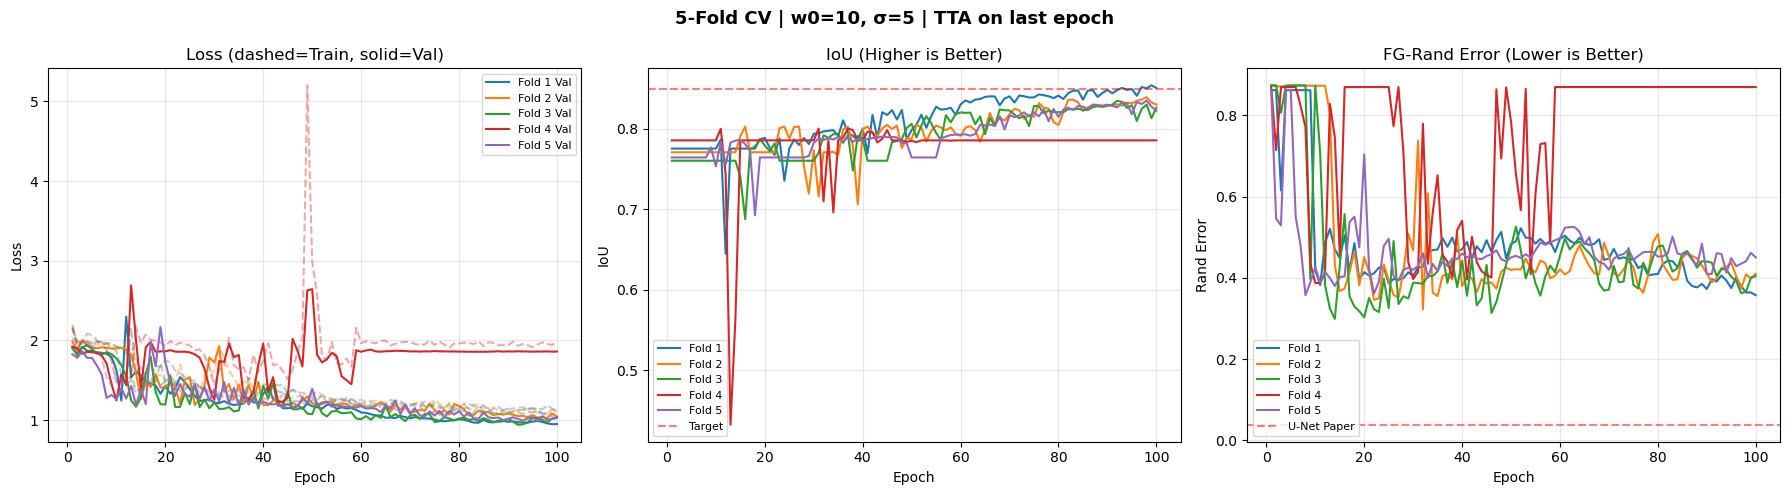

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, history in enumerate(all_fold_histories):
    c = colors[i]
    axes[0].plot(history['epochs'], history['train_loss'], color=c, alpha=0.4, linestyle='--')
    axes[0].plot(history['epochs'], history['val_loss'], color=c, label=f'Fold {i+1} Val')
    axes[1].plot(history['epochs'], history['val_iou'], color=c, label=f'Fold {i+1}')
    axes[2].plot(history['epochs'], history['val_rand_error'], color=c, label=f'Fold {i+1}')

axes[0].set_title('Loss (dashed=Train, solid=Val)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].set_title('IoU (Higher is Better)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('IoU')
axes[1].axhline(y=0.85, color='r', linestyle='--', alpha=0.5, label='Target')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

axes[2].set_title('FG-Rand Error (Lower is Better)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Rand Error')
axes[2].axhline(y=0.0382, color='r', linestyle='--', alpha=0.5, label='U-Net Paper')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{config.n_folds}-Fold CV | w0={config.w0}, σ={config.sigma_weight} | TTA on last epoch', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kfold_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
history = {
    'train_loss': [],
    'val_loss': [],
    'val_iou': [],
    'val_warping_error': [],
    'val_randing_error' : [],
    'epochs': [],
    'learning_rate': []
}

# Training loop
best_iou = 0
best_warping_error = float('inf')

for epoch in range(config.num_epochs):
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_iou, val_warp_error, val_rand_error = validate(model, val_loader, criterion, device)

    # Scheduler
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    history['epochs'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    history['val_warping_error'].append(val_warp_error)
    history['val_randing_error'].append(val_rand_error)
    history['learning_rate'].append(current_lr) 
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{config.num_epochs}")
        print(f"  LR: {current_lr:.6f}")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss: {val_loss:.4f}, IoU: {val_iou:.4f}")
        print(f"  Warp: {val_warp_error:.4f}, Rand: {val_rand_error:.4f}")
        print("-" * 50)
    
    # Save best model (based on warping error - lower is better)
    if val_warp_error < best_warping_error:
        best_warping_error = val_warp_error
        best_iou = val_iou
        torch.save(model.state_dict(), 'U-net(EMsegmentation)_basic.pth')
        print(f'✓ Saved best model with Warping Error: {best_warping_error:.4f} (IoU: {best_iou:.4f})\n')


Epoch 1/100
  LR: 0.010000
  Train Loss: 1.7841
  Val Loss: 1.8015, IoU: 0.7582
  Warp: 0.9826, Rand: 0.9003
--------------------------------------------------
✓ Saved best model with Warping Error: 0.9826 (IoU: 0.7582)

Epoch 5/100
  LR: 0.010000
  Train Loss: 1.8121
  Val Loss: 1.7982, IoU: 0.7582
  Warp: 0.9826, Rand: 0.9003
--------------------------------------------------
Epoch 10/100
  LR: 0.010000
  Train Loss: 1.3050
  Val Loss: 1.3149, IoU: 0.7582
  Warp: 0.9826, Rand: 0.9003
--------------------------------------------------
✓ Saved best model with Warping Error: 0.4596 (IoU: 0.7799)

Epoch 15/100
  LR: 0.010000
  Train Loss: 1.3605
  Val Loss: 1.4543, IoU: 0.7747
  Warp: 0.4827, Rand: 0.1173
--------------------------------------------------
Epoch 20/100
  LR: 0.010000
  Train Loss: 1.5301
  Val Loss: 1.3102, IoU: 0.7582
  Warp: 0.9826, Rand: 0.9003
--------------------------------------------------
Epoch 25/100
  LR: 0.008000
  Train Loss: 1.6837
  Val Loss: 1.7056, IoU: 0

In [20]:
# 배치 하나만 꺼내서 확인
batch = next(iter(train_loader))

print(f"Image range: [{batch['image'].min():.2f}, {batch['image'].max():.2f}]")
print(f"Mask unique values: {torch.unique(batch['mask'])}")
print(f"Weight map range: [{batch['weight_map'].min():.2f}, {batch['weight_map'].max():.2f}]")
print(f"Weight map has NaN: {torch.isnan(batch['weight_map']).any()}")
print(f"Weight map has Inf: {torch.isinf(batch['weight_map']).any()}")

# 모델 출력 확인
model.eval()
with torch.no_grad():
    preds = model(batch['image'].to(device))
    print(f"\nPred range: [{preds.min():.2f}, {preds.max():.2f}]")
    print(f"Pred has NaN: {torch.isnan(preds).any()}")

# Loss 각각 확인
masks = batch['mask'].to(device)
wmaps = batch['weight_map'].float().to(device)
_, _, h, w = preds.shape
masks = center_crop(masks, h, w)
wmaps = center_crop(wmaps, h, w)

combined, ce, dice = criterion(preds, masks, wmaps)
print(f"\nCE Loss: {ce:.4f}")
print(f"Dice Loss: {dice:.4f}")
print(f"Combined Loss: {combined:.4f}")

Image range: [0.00, 1.00]
Mask unique values: tensor([0., 1.])
Weight map range: [1.00, 27.85]
Weight map has NaN: False
Weight map has Inf: False

Pred range: [-3.59, 3.75]
Pred has NaN: False

CE Loss: 1.1247
Dice Loss: 0.1869
Combined Loss: 1.3115


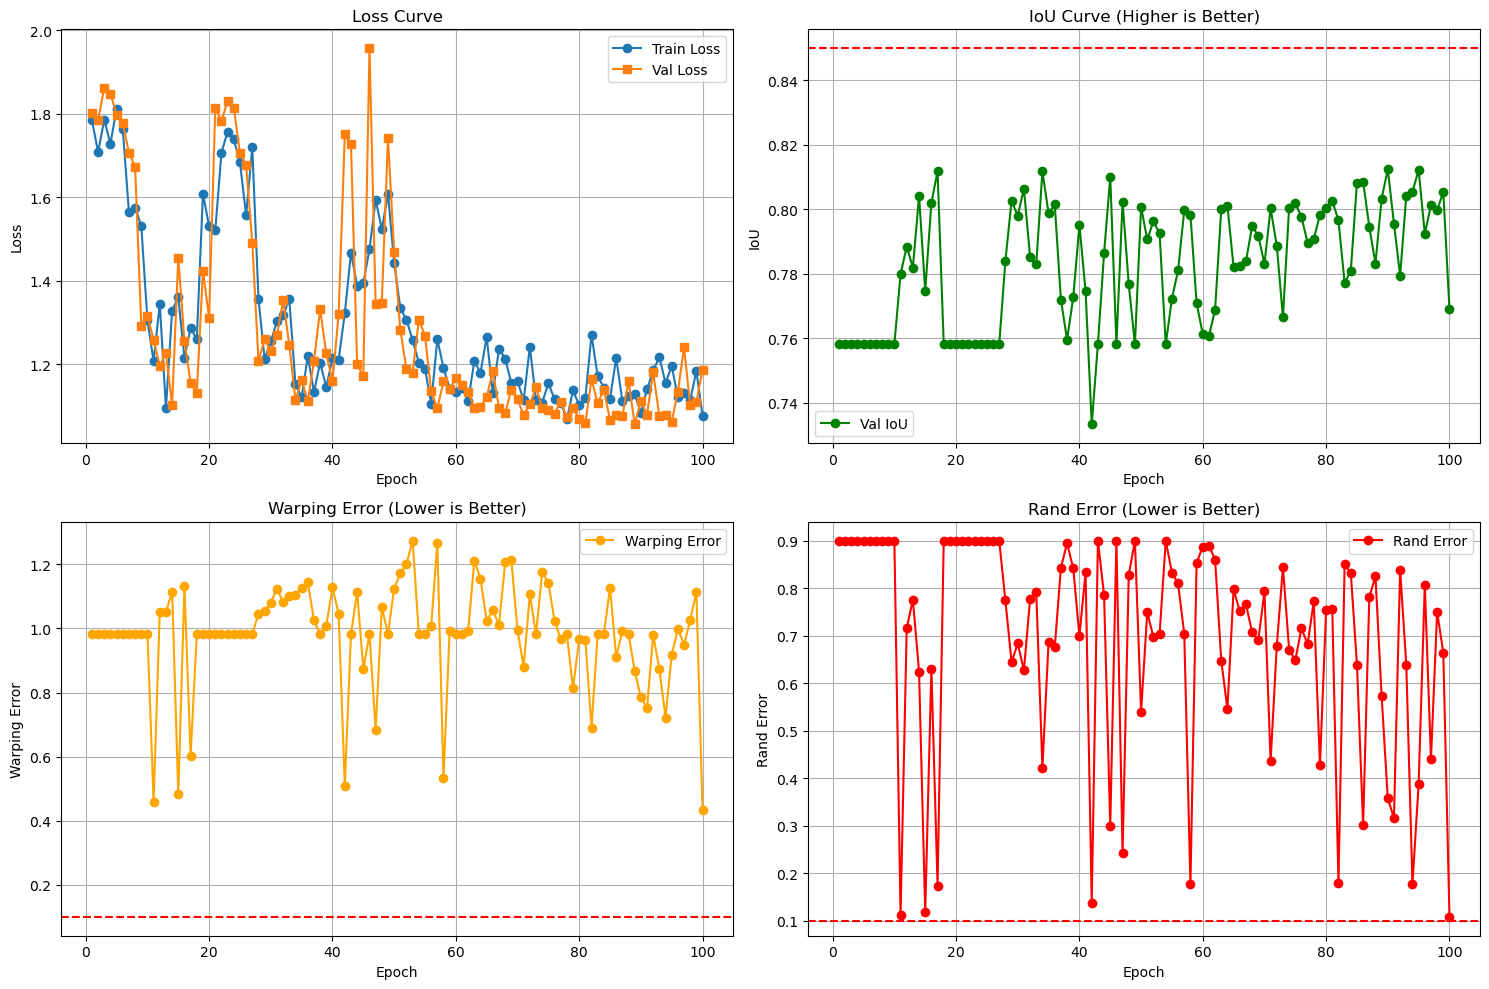

Training Statistics

Best Epoch:
  Best Val Error: 0.1080 at Epoch 89
  Best IoU: 0.8124 at Epoch 90
  Best Warping Error: 0.4321 at Epoch 100
  Best Rand Error: 0.1080 at Epoch 100

Final Epoch:
  Train Loss: 1.0762
  Val Loss: 1.1870
  Val IoU: 0.7690
  Warping Error: 0.4321
  Rand Error: 0.1080

Improvement:
  IoU: 0.7582 → 0.7690 (+0.0108)
  Warp: 0.9826 → 0.4321 (-0.5505)
  Rand: 0.9003 → 0.1080 (-0.7924)


In [21]:
import matplotlib.pyplot as plt

# 그래프 그리기
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Loss (Train vs Val)
ax = axes[0, 0]
ax.plot(history['epochs'], history['train_loss'], label='Train Loss', marker='o')
ax.plot(history['epochs'], history['val_loss'], label='Val Loss', marker='s')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss Curve')
ax.legend()
ax.grid(True)

# 2. IoU
ax = axes[0, 1]
ax.plot(history['epochs'], history['val_iou'], label='Val IoU', marker='o', color='green')
ax.set_xlabel('Epoch')
ax.set_ylabel('IoU')
ax.set_title('IoU Curve (Higher is Better)')
ax.legend()
ax.grid(True)
ax.axhline(y=0.85, color='r', linestyle='--', label='Target (0.85)')

# 3. Warping Error
ax = axes[1, 0]
ax.plot(history['epochs'], history['val_warping_error'], label='Warping Error', marker='o', color='orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('Warping Error')
ax.set_title('Warping Error (Lower is Better)')
ax.legend()
ax.grid(True)
ax.axhline(y=0.1, color='r', linestyle='--', label='Target (0.1)')

# 4. Rand Error
ax = axes[1, 1]
ax.plot(history['epochs'], history['val_randing_error'], label='Rand Error', marker='o', color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Rand Error')
ax.set_title('Rand Error (Lower is Better)')
ax.legend()
ax.grid(True)
ax.axhline(y=0.1, color='r', linestyle='--', label='Target (0.1)')

plt.tight_layout()
plt.savefig('(basic)training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# 통계 출력
print("="*50)
print("Training Statistics")
print("="*50)
print(f"\nBest Epoch:")
best_val_epoch = history['epochs'][np.argmin(history['val_loss'])]
best_val = np.min(history['val_randing_error'])
print(f"  Best Val Error: {best_val:.4f} at Epoch {best_val_epoch}")

best_iou_epoch = history['epochs'][np.argmax(history['val_iou'])]
best_iou = np.max(history['val_iou'])
print(f"  Best IoU: {best_iou:.4f} at Epoch {best_iou_epoch}")

best_warp_epoch = history['epochs'][np.argmin(history['val_warping_error'])]
best_warp = np.min(history['val_warping_error'])
print(f"  Best Warping Error: {best_warp:.4f} at Epoch {best_warp_epoch}")

best_rand_epoch = history['epochs'][np.argmin(history['val_randing_error'])]
best_rand = np.min(history['val_randing_error'])
print(f"  Best Rand Error: {best_rand:.4f} at Epoch {best_rand_epoch}")

print(f"\nFinal Epoch:")
print(f"  Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Val Loss: {history['val_loss'][-1]:.4f}")
print(f"  Val IoU: {history['val_iou'][-1]:.4f}")
print(f"  Warping Error: {history['val_warping_error'][-1]:.4f}")
print(f"  Rand Error: {history['val_randing_error'][-1]:.4f}")

print(f"\nImprovement:")
print(f"  IoU: {history['val_iou'][0]:.4f} → {history['val_iou'][-1]:.4f} ({history['val_iou'][-1] - history['val_iou'][0]:+.4f})")
print(f"  Warp: {history['val_warping_error'][0]:.4f} → {history['val_warping_error'][-1]:.4f} ({history['val_warping_error'][-1] - history['val_warping_error'][0]:+.4f})")
print(f"  Rand: {history['val_randing_error'][0]:.4f} → {history['val_randing_error'][-1]:.4f} ({history['val_randing_error'][-1] - history['val_randing_error'][0]:+.4f})")

In [57]:
# 확인해보세요
batch = next(iter(train_loader))
print(f"Image range: [{batch['image'].min():.2f}, {batch['image'].max():.2f}]")
print(f"Mask values: {torch.unique(batch['mask'])}")
print(f"Weight map range: [{batch['weight_map'].min():.2f}, {batch['weight_map'].max():.2f}]")

Image range: [0.00, 1.00]
Mask values: tensor([0., 1.])
Weight map range: [1.00, 27.85]


In [58]:
# 모델이 제대로 예측하는지
preds = model(batch['image'].to(device))
print(f"Pred range: [{preds.min():.2f}, {preds.max():.2f}]")
print(f"Pred after sigmoid: [{torch.sigmoid(preds).min():.2f}, {torch.sigmoid(preds).max():.2f}]")

Pred range: [-3.50, 10.81]
Pred after sigmoid: [0.03, 1.00]


In [59]:
# Weight map이 너무 크면 loss가 폭발할 수 있음
print(f"Weight map max: {batch['weight_map'].max():.2f}")
# 만약 100 이상이면 문제!

Weight map max: 27.85


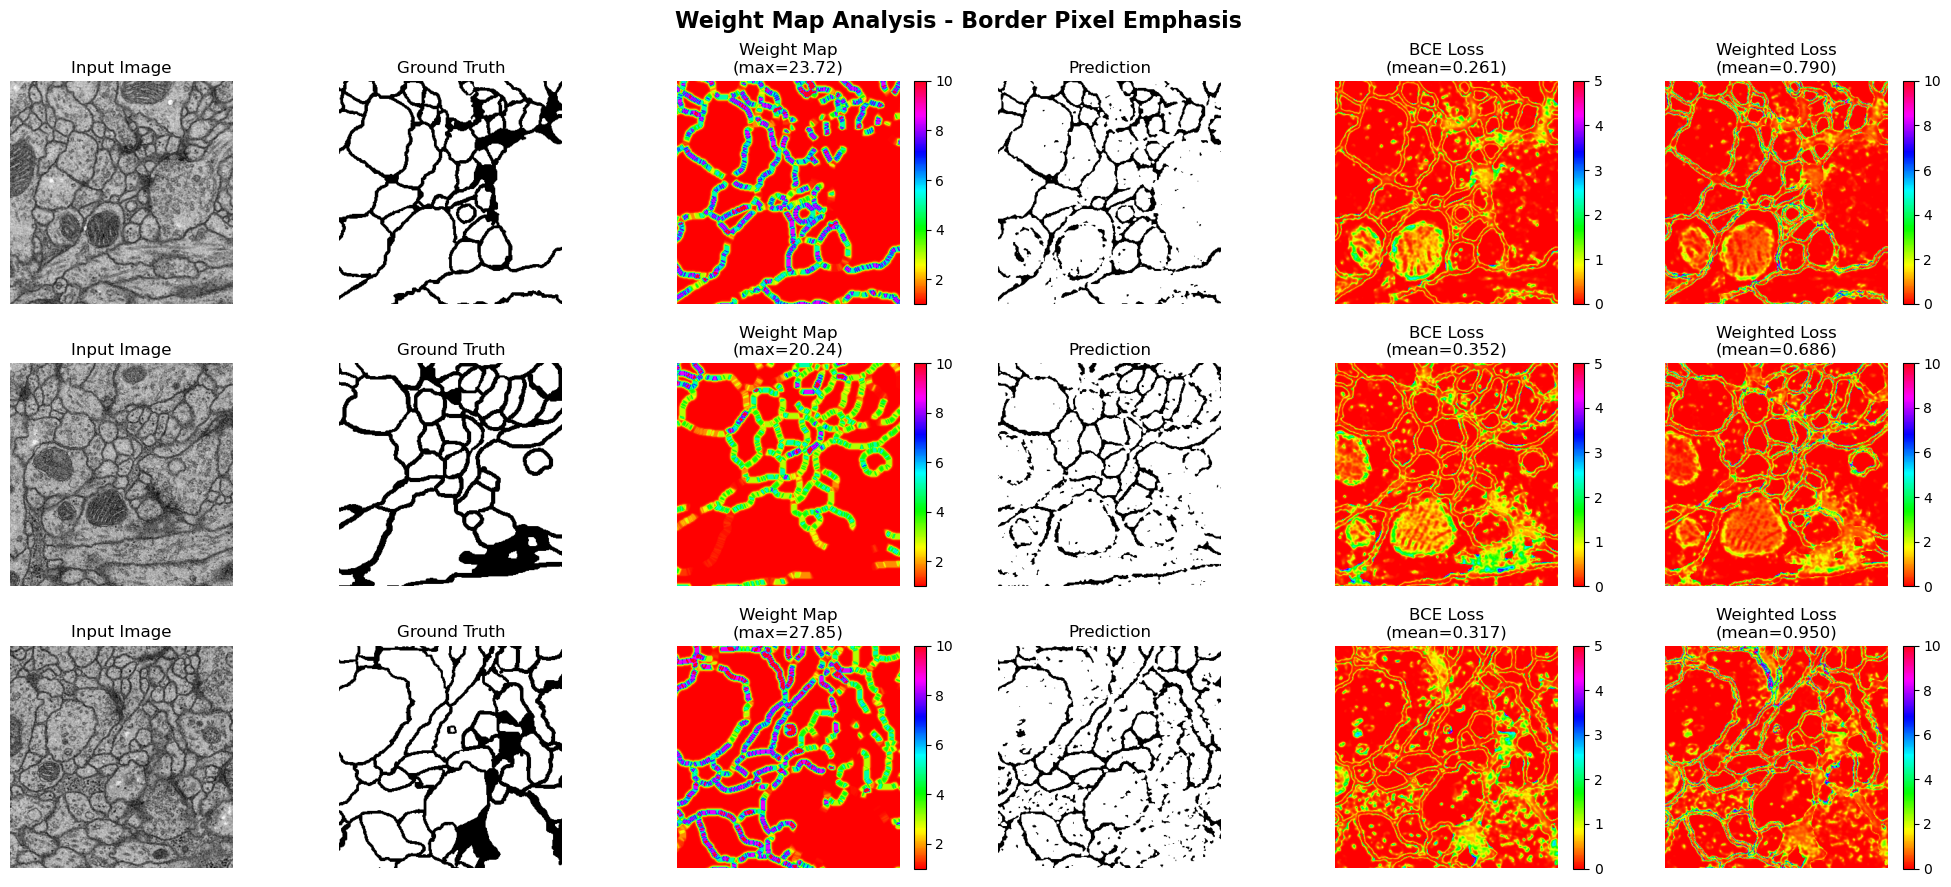

WEIGHT MAP STATISTICS
Weight Map Range: [1.00, 27.85]
Weight Map Mean: 2.11

BCE Loss (before weight):
  Mean: 0.3099
  Max: 5.8244

Weighted Loss (after weight):
  Mean: 0.8085
  Max: 72.8033

Loss Amplification: 2.61x


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_weight_map(model, val_loader, device, num_samples=3):
    """
    Weight map이 경계에 제대로 적용되는지 시각화
    """
    model.eval()
    
    fig, axes = plt.subplots(num_samples, 6, figsize=(20, num_samples*3))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    with torch.no_grad():
        batch = next(iter(val_loader))
        
        imgs = batch['image'].to(device)
        masks = batch['mask'].to(device)
        wmaps = batch['weight_map'].to(device)
        
        # 모델 예측
        preds = model(imgs)
        preds_prob = torch.softmax(preds, dim=1)[:, 1:2, :, :]
        preds_binary = (preds_prob > config.threshold).float()
        
        # Center crop
        _, _, h, w = preds.shape
        masks_cropped = center_crop(masks, h, w)
        wmaps_cropped = center_crop(wmaps, h, w)
        
        # Loss 계산 (픽셀별)
        criterion = WeightedCELoss()
        bce_loss = torch.nn.functional.binary_cross_entropy_with_logits(
            preds, masks_cropped, reduction='none'
        )
        weighted_loss = bce_loss * wmaps_cropped
        
        # CPU로 이동
        imgs_np = imgs.cpu().numpy()
        masks_np = masks_cropped.cpu().numpy()
        wmaps_np = wmaps_cropped.cpu().numpy()
        preds_np = preds_binary.cpu().numpy()
        bce_loss_np = bce_loss.cpu().numpy()
        weighted_loss_np = weighted_loss.cpu().numpy()
        
        for i in range(min(num_samples, imgs_np.shape[0])):
            # 1. 원본 이미지
            axes[i, 0].imshow(imgs_np[i, 0], cmap='gray')
            axes[i, 0].set_title('Input Image')
            axes[i, 0].axis('off')
            
            # 2. Ground Truth Mask
            axes[i, 1].imshow(masks_np[i, 0], cmap='gray')
            axes[i, 1].set_title('Ground Truth')
            axes[i, 1].axis('off')
            
            # 3. Weight Map (경계가 밝게 나와야 함!)
            wmap_img = axes[i, 2].imshow(wmaps_np[i, 0], cmap='hsv', vmin=1, vmax=10)
            axes[i, 2].set_title(f'Weight Map\n(max={wmaps_np[i, 0].max():.2f})')
            axes[i, 2].axis('off')
            plt.colorbar(wmap_img, ax=axes[i, 2], fraction=0.046)
            
            # 4. 예측 결과
            axes[i, 3].imshow(preds_np[i, 0], cmap='gray')
            axes[i, 3].set_title('Prediction')
            axes[i, 3].axis('off')
            
            # 5. BCE Loss (weight 적용 전)
            bce_img = axes[i, 4].imshow(bce_loss_np[i, 0], cmap='hsv', vmin=0, vmax=5)
            axes[i, 4].set_title(f'BCE Loss\n(mean={bce_loss_np[i, 0].mean():.3f})')
            axes[i, 4].axis('off')
            plt.colorbar(bce_img, ax=axes[i, 4], fraction=0.046)
            
            # 6. Weighted Loss (weight 적용 후)
            weighted_img = axes[i, 5].imshow(weighted_loss_np[i, 0], cmap='hsv', vmin=0, vmax=10)
            axes[i, 5].set_title(f'Weighted Loss\n(mean={weighted_loss_np[i, 0].mean():.3f})')
            axes[i, 5].axis('off')
            plt.colorbar(weighted_img, ax=axes[i, 5], fraction=0.046)
    
    plt.suptitle('Weight Map Analysis - Border Pixel Emphasis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('(basic)weight_map_threshold_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 통계 출력
    print("="*70)
    print("WEIGHT MAP STATISTICS")
    print("="*70)
    print(f"Weight Map Range: [{wmaps_np.min():.2f}, {wmaps_np.max():.2f}]")
    print(f"Weight Map Mean: {wmaps_np.mean():.2f}")
    print(f"\nBCE Loss (before weight):")
    print(f"  Mean: {bce_loss_np.mean():.4f}")
    print(f"  Max: {bce_loss_np.max():.4f}")
    print(f"\nWeighted Loss (after weight):")
    print(f"  Mean: {weighted_loss_np.mean():.4f}")
    print(f"  Max: {weighted_loss_np.max():.4f}")
    print(f"\nLoss Amplification: {weighted_loss_np.mean() / bce_loss_np.mean():.2f}x")


# 실행
visualize_weight_map(model, val_loader, device, num_samples=3)

1. base
2. Adding Learning Scheduler
3. Modifying w0=10 > w0=30
4. Modifying w0=10 > w0=30, sigma_weight=5 > sigma_weight=3
5. threshold=0.5 > threshold=0.3
6. Modifying w0=50

SIGMOID DISTRIBUTION
배경:    mean=0.233, max=0.976
경계:    mean=0.479, min=0.012
내부:    mean=0.841

경계 픽셀 confidence:
  > 0.3: 64.8%
  > 0.4: 53.6%
  > 0.5: 44.0%
  > 0.6: 36.0%
  > 0.7: 28.1%


/var/folders/21/9992qlf90l12528ffgh05tw80000gn/T/ipykernel_26932/3849524928.py:74: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/21/9992qlf90l12528ffgh05tw80000gn/T/ipykernel_26932/3849524928.py:74: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/21/9992qlf90l12528ffgh05tw80000gn/T/ipykernel_26932/3849524928.py:74: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/21/9992qlf90l12528ffgh05tw80000gn/T/ipykernel_26932/3849524928.py:74: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/21/9992qlf90l12528ffgh05tw80000gn/T/ipykernel_26932/3849524928.py:74: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/21/9992qlf90l12528ffgh05tw80000gn/T/ipyk

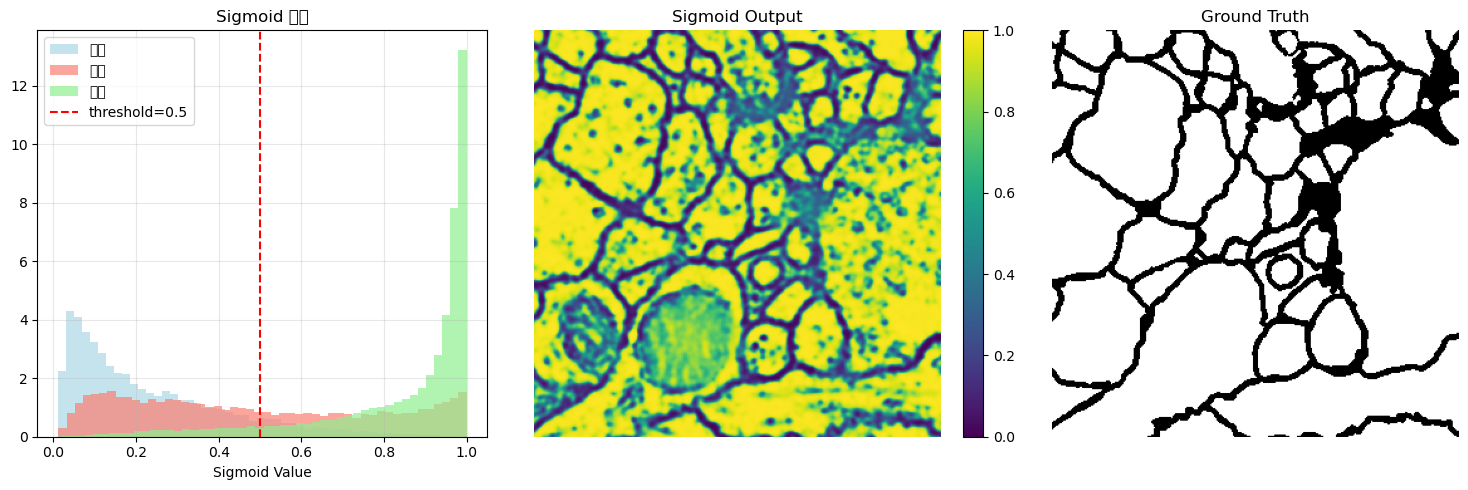

'\n## 분포 확인 후 해결책:\n\n### **Case A: 경계/배경 분포가 겹침** (가장 흔한 경우)\n배경:  0.1 ~ 0.5  ← 넓게 퍼짐\n경계:  0.3 ~ 0.8  ← 넓게 퍼짐\n겹치는 구간: 0.3 ~ 0.5\n'

In [37]:
def check_sigmoid_distribution(model, val_loader, device):
    """
    경계 vs 배경의 sigmoid 분포 확인
    """
    from scipy.ndimage import binary_dilation, binary_erosion
    
    model.eval()
    
    with torch.no_grad():
        batch = next(iter(val_loader))
        imgs = batch['image'].to(device)
        masks = batch['mask'].to(device)
        
        preds = model(imgs)
        preds_sigmoid = torch.sigmoid(preds)
        
        # Center crop
        _, _, h, w = preds.shape
        masks_cropped = center_crop(masks, h, w)
        
        # Numpy
        sigmoid_np = preds_sigmoid.cpu().numpy()[0, 0]
        mask_np = masks_cropped.cpu().numpy()[0, 0]
        
        # 경계/내부/배경 분리
        mask_binary = (mask_np > 0).astype(np.uint8)
        dilated = binary_dilation(mask_binary)
        eroded = binary_erosion(mask_binary)
        
        boundary = dilated & ~eroded
        interior = eroded.astype(bool)
        background = ~dilated.astype(bool)
        
        # 분포 출력
        print("="*70)
        print("SIGMOID DISTRIBUTION")
        print("="*70)
        print(f"배경:    mean={sigmoid_np[background].mean():.3f}, max={sigmoid_np[background].max():.3f}")
        print(f"경계:    mean={sigmoid_np[boundary].mean():.3f}, min={sigmoid_np[boundary].min():.3f}")
        print(f"내부:    mean={sigmoid_np[interior].mean():.3f}")
        
        # 경계 픽셀 중 threshold별 비율
        print(f"\n경계 픽셀 confidence:")
        for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
            ratio = (sigmoid_np[boundary] > t).sum() / boundary.sum() * 100
            print(f"  > {t}: {ratio:.1f}%")
        
        # 시각화
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        axes[0].hist(sigmoid_np[background].flatten(), bins=50, 
                    alpha=0.7, color='lightblue', label='배경', density=True)
        axes[0].hist(sigmoid_np[boundary].flatten(), bins=50,
                    alpha=0.7, color='salmon', label='경계', density=True)
        axes[0].hist(sigmoid_np[interior].flatten(), bins=50,
                    alpha=0.7, color='lightgreen', label='내부', density=True)
        axes[0].axvline(x=0.5, color='red', linestyle='--', label='threshold=0.5')
        axes[0].set_xlabel('Sigmoid Value')
        axes[0].set_title('Sigmoid 분포')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Sigmoid 원본
        axes[1].imshow(sigmoid_np, cmap='viridis', vmin=0, vmax=1)
        axes[1].set_title('Sigmoid Output')
        axes[1].axis('off')
        plt.colorbar(axes[1].images[0], ax=axes[1], fraction=0.046)
        
        # GT
        axes[2].imshow(mask_np, cmap='gray')
        axes[2].set_title('Ground Truth')
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.savefig('sigmoid_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()

check_sigmoid_distribution(model, val_loader, device)
'''
## 분포 확인 후 해결책:

### **Case A: 경계/배경 분포가 겹침** (가장 흔한 경우)
배경:  0.1 ~ 0.5  ← 넓게 퍼짐
경계:  0.3 ~ 0.8  ← 넓게 퍼짐
겹치는 구간: 0.3 ~ 0.5
'''

In [38]:
print(f"Train dataset 크기: {len(train_dataset)}")
print(f"Val dataset 크기: {len(val_dataset)}")

# DataLoader로 확인
print(f"Train batches: {len(train_loader)}")
print(f"Batch size: {train_loader.batch_size}")
print(f"총 Train patches: {len(train_loader) * train_loader.batch_size}")

Train dataset 크기: 27
Val dataset 크기: 3
Train batches: 14
Batch size: 2
총 Train patches: 28


In [39]:
# 현재 패치 추출 코드가 어떻게 되어있어요?
print(train_dataset.__class__)  # 클래스 이름 확인

# 패치 크기 확인
sample = train_dataset[0]
print(f"Image shape: {sample['image'].shape}")
print(f"Mask shape: {sample['mask'].shape}")

<class '__main__.EMDataset'>
Image shape: torch.Size([1, 572, 572])
Mask shape: torch.Size([1, 572, 572])


In [40]:
# train_transform이 어떻게 되어있어요?
print(train_transform)

<function train_transform at 0x15b08eb00>
